In [1]:
import sqlite3

In [2]:
import pandas as pd

In [3]:
conn = sqlite3.connect('data/hm.db')

In [4]:
retention = pd.read_sql("select * from cohort_retention", conn)

In [5]:
retention.head()

,cohort_month,month,month_n,active_users,cohort_size,retention_pct
0,2018-09,2018-09,0,140340,140340,100.00
1,2018-09,2018-10,1,61551,140340,43.86
2,2018-09,2018-11,2,59793,140340,42.61
3,2018-09,2018-12,3,56736,140340,40.43
4,2018-09,2019-01,4,53683,140340,38.25


In [6]:
pivot = retention.pivot_table(index='cohort_month', columns='month_n', values='retention_pct')

In [7]:
pivot

month_n,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
cohort_month,,,,,,,,,,,,,,,,,,,,,
2018-09,100.0,43.86,42.61,40.43,38.25,36.18,37.94,39.40,39.43,42.70,...,35.09,31.56,30.35,27.58,26.80,30.06,36.57,32.80,31.52,24.3
2018-10,100.0,35.82,33.35,31.68,29.61,31.09,32.58,33.00,35.79,34.66,...,25.88,24.86,22.43,21.71,24.70,30.76,27.43,25.99,19.32,NaN
2018-11,100.0,26.37,23.91,22.22,23.57,24.61,25.27,27.97,26.76,21.27,...,18.78,16.77,16.45,18.99,23.91,21.34,19.84,14.40,NaN,NaN
2018-12,100.0,21.08,18.50,19.39,20.49,21.15,23.70,23.43,18.10,17.91,...,13.93,13.60,16.33,20.64,18.70,17.16,12.04,NaN,NaN,NaN
2019-01,100.0,18.04,17.87,18.75,19.21,21.17,20.79,16.05,16.26,16.60,...,13.33,14.71,18.49,16.47,15.56,10.74,NaN,NaN,NaN,NaN
2019-02,100.0,17.20,16.92,17.08,18.85,18.31,14.03,13.95,14.26,14.76,...,12.92,15.76,13.95,12.98,9.63,NaN,NaN,NaN,NaN,NaN
2019-03,100.0,19.45,18.43,20.30,19.14,14.44,15.04,15.07,15.76,14.89,...,17.13,14.77,13.65,9.91,NaN,NaN,NaN,NaN,NaN,NaN
2019-04,100.0,19.20,19.51,18.29,13.64,13.44,14.22,14.76,13.71,11.82,...,14.09,12.89,9.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-05,100.0,20.53,17.93,13.13,13.33,13.39,13.87,13.51,11.53,11.29,...,12.41,8.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
import matplotlib.pyplot as plt

In [9]:
import seaborn as sns

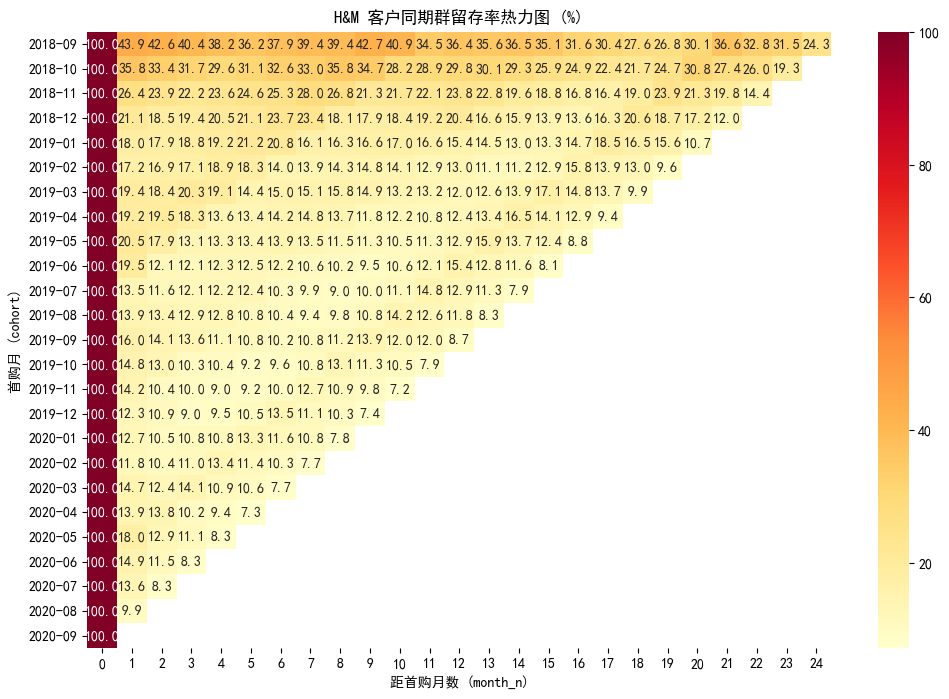

In [10]:
# 中文字体（不然图里中文显示成方块）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('H&M 客户同期群留存率热力图 (%)')
plt.xlabel('距首购月数 (month_n)')
plt.ylabel('首购月 (cohort)')

plt.savefig('outputs/留存热力图.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
seg = pd.read_sql("""
SELECT segment,
       COUNT(*) AS customers,
       ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS customer_pct,
       ROUND(SUM(monetary) * 100.0 / SUM(SUM(monetary)) OVER (), 1) AS revenue_pct
FROM rfm_segment
GROUP BY segment
""", conn)

seg.sort_values('revenue_pct', ascending=False)

,segment,customers,customer_pct,revenue_pct
4,重要价值客户,337152,24.7,66.6
5,重要保持客户,131296,9.6,16.1
3,流失客服,595126,43.7,7.8
7,重要挽留客户,55026,4.0,3.5
2,一般发展客户,145779,10.7,2.3
6,重要发展客户,21438,1.6,1.3
0,一般价值客户,40543,3.0,1.2
1,一般保持客户,35921,2.6,1.1


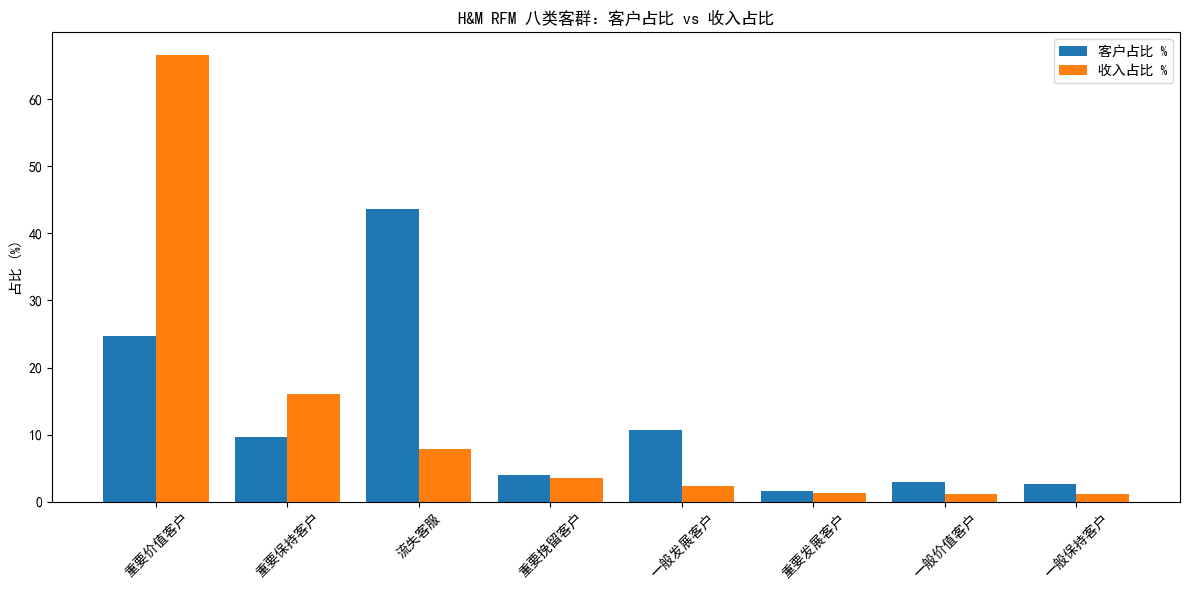

In [12]:
seg = seg.sort_values('revenue_pct', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(seg))
plt.bar(x, seg['customer_pct'], width=0.4, label='客户占比 %')
plt.bar([i + 0.4 for i in x], seg['revenue_pct'], width=0.4, label='收入占比 %')
plt.xticks([i + 0.2 for i in x], seg['segment'], rotation=45)
plt.ylabel('占比 (%)')
plt.title('H&M RFM 八类客群：客户占比 vs 收入占比')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/RFM分层图.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# 读品类收入
cat = pd.read_sql("""
SELECT product_group_name, category_revenue
FROM category_revenue
ORDER BY category_revenue DESC
""", conn)

In [14]:
# 算累计占比（cumsum = 累加，跟 SQL 的 OVER ORDER BY 一个意思）
cat['cum_pct'] = cat['category_revenue'].cumsum() / cat['category_revenue'].sum() * 100

In [15]:
cat

,product_group_name,category_revenue,cum_pct
0,Garment Upper body,338981.789203,38.318355
1,Garment Lower body,231774.620034,64.518059
2,Garment Full body,128478.941678,79.041263
3,Swimwear,57628.166508,85.555526
4,Underwear,54395.857458,91.704410
5,Shoes,28888.356373,94.969938
6,Accessories,24893.822424,97.783925
7,Nightwear,8852.815390,98.784643
8,Socks & Tights,7811.136525,99.667611
9,Unknown,2598.734051,99.961370


C:\Users\34327\AppData\Local\Temp\ipykernel_35160\3768358561.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cat['product_group_name'], rotation=45, ha='right')


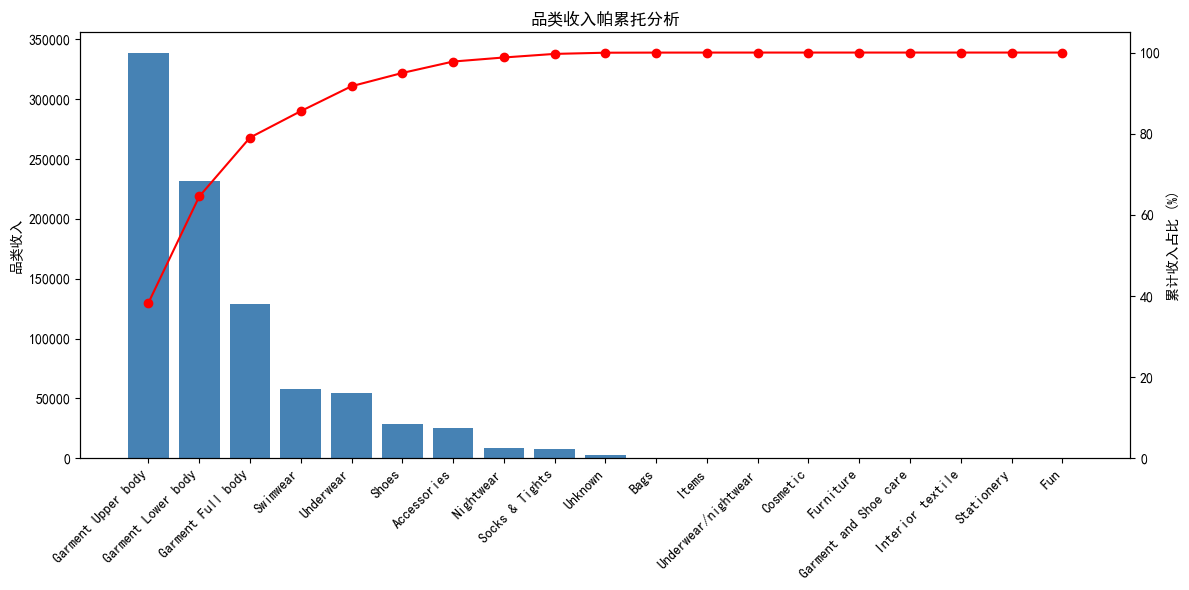

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 左轴：柱状图 = 品类收入
ax1.bar(cat['product_group_name'], cat['category_revenue'], color='steelblue')
ax1.set_ylabel('品类收入')
ax1.set_xticklabels(cat['product_group_name'], rotation=45, ha='right')

# 右轴：折线 = 累计占比
ax2 = ax1.twinx()
ax2.plot(cat['product_group_name'], cat['cum_pct'], color='red', marker='o')
ax2.set_ylabel('累计收入占比 (%)')
ax2.set_ylim(0, 105)

plt.title('品类收入帕累托分析')

# 先保存，再显示（同一 cell，顺序不能反）
plt.tight_layout()
plt.savefig('outputs/帕累托曲线.png', dpi=150, bbox_inches='tight')
plt.show()